# Praktikum Machine Learning: Bab 5
## Decision Tree: Algoritma CART/ID3 dan Teknik Pruning

| | |
|---|---|
| **Nama** | Ahmad Dandi Subhani |
| **NPM** | 202343500126 |
| **Kelas** | R7B |
| **Mata Kuliah** | Machine Learning |
| **Dosen** | Nurfidah Dwitiyanti, M.Si. |

> **Catatan:** notebook ini saya jalanin di **Google Colab / Jupyter Notebook**. Dataset yang saya pake: Breast Cancer Wisconsin dari sklearn.datasets (569 pasien, 30 fitur), filenya `data/breast_cancer.csv`. Jadi nggak perlu unduh file eksternal.

## Ringkasan Konsep

**Decision Tree (pohon keputusan)** itu model klasifikasi yang kerjanya ngebagi data secara **rekursif (recursive binary splitting)**: mulai dari *root node*, tiap *internal node* milih satu fitur sama satu nilai ambang (*threshold*) buat misahin data jadi dua cabang, terus prosesnya diulang di tiap cabang sampe kebentuk *leaf node* (daun) yang isinya label kelas prediksi. Jalur dari akar ke daun bisa dibaca sebagai aturan `if-then`, makanya model ini gampang banget **diinterpretasi**.

**Kriteria pemilihan split.** Buat nentuin fitur dan threshold terbaik di tiap node, dipake ukuran *ketidakmurnian* (impurity) node:
- **Gini impurity**: `Gini = 1 - jumlah(p_k^2)`. Makin kecil makin murni. Cepet dihitung dan jadi default di scikit-learn.
- **Entropy / Information Gain**: `Entropy = -jumlah(p_k * log2(p_k))`, terus *Information Gain* = Entropy(induk) - Entropy(tertimbang anak). Split dengan Information Gain terbesar yang dipilih.

Keduanya biasanya ngasih hasil mirip sih. Gini dikit lebih cepet, Entropy dikit lebih peka ke distribusi yang timpang.

**CART vs ID3.** *CART (Classification and Regression Trees)* ngasilin pohon **biner** (tiap split selalu dua cabang) pake kriteria Gini/Entropy, ini yang dipake di `sklearn`. *ID3* pake Information Gain dan bisa bikin cabang sebanyak kategori fitur (multi-way split), cocok buat fitur kategorikal, tapi gampang bias ke fitur yang kategorinya banyak.

**Overfitting pada tree.** Pohon yang nggak dibatesin bakal tumbuh sampe tiap daun murni. Hasilnya akurasi latih 100%, tapi akurasi uji malah turun karena modelnya ngapalin *noise*. Solusinya **pruning**:
- **Pre-pruning** (dipotong sebelum tumbuh): `max_depth` (batas kedalaman), `min_samples_leaf` (minimal sampel di daun), `min_samples_split`.
- **Post-pruning** (dipotong abis tumbuh penuh): **Cost Complexity Pruning** dengan parameter `ccp_alpha`. Cabang yang perbaikin impurity-nya lebih kecil dari `alpha` dipangkas. `alpha` yang optimal dipilih dari *pruning path*, bukan dari sekali tebak.

## Praktikum

### Praktikum 5.1 - Persiapan Library (Modul Bab 5, bagian 5.11)

Bagian ini saya ngerjain Praktikum 5.1 dari Modul Machine Learning Bab 5. Pertama saya import semua library yang dibutuhin dulu: `numpy`/`pandas` buat data, `matplotlib` buat plot, terus `train_test_split`, `DecisionTreeClassifier`, `plot_tree`, sama metrik evaluasi dari scikit-learn.

In [1]:
%matplotlib inline
# Menjalankan di Google Colab / Jupyter Notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

print("Library berhasil dimuat.")

Library berhasil dimuat.


**Penjelasan outputnya:**
- Nggak ada error `ModuleNotFoundError`, artinya `numpy`, `pandas`, `matplotlib`, sama `scikit-learn` udah tersedia di environment ini.
- Pesan `"Library berhasil dimuat."` kecetak, berarti environment-nya siap buat praktikum. Lanjut!

### Praktikum 5.2 - Memuat Dataset Breast Cancer (Modul Bab 5, bagian 5.11)

Bagian ini saya ngerjain Praktikum 5.2 dari Modul Machine Learning Bab 5. Dataset yang saya pake: Breast Cancer Wisconsin dari sklearn.datasets (569 pasien, 30 fitur), filenya `data/breast_cancer.csv`. Dibaca pake `pd.read_csv` biar bisa jalan offline. Dataset ini isinya hasil pengukuran citra biopsi benjolan payudara, ada 2 kelas: `malignant` (ganas) sama `benign` (jinak). Terus saya cetak ukuran dataset sama distribusi kelasnya.

In [2]:
# Dataset dibaca dari file CSV lokal (data/breast_cancer.csv) - bisa dipakai offline
# (diekspor dari sklearn.datasets.load_breast_cancer, data real)
df = pd.read_csv('data/breast_cancer.csv')
feature_names = [c for c in df.columns if c not in ('target', 'target_name')]
target_names = ['malignant', 'benign']  # 0 = malignant, 1 = benign
X = df[feature_names]  # fitur: 30 hasil pengukuran citra biopsi
y = df['target']       # target: 0 = malignant, 1 = benign

print("Ukuran dataset (baris, kolom):", X.shape)
print("Jumlah fitur:", X.shape[1])
print("\nDaftar nama fitur (5 pertama):", list(X.columns[:5]))
print("\nDistribusi kelas:")
print(y.value_counts())
print("Nama kelas:", target_names)

Ukuran dataset (baris, kolom): (569, 30)
Jumlah fitur: 30

Daftar nama fitur (5 pertama): ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']

Distribusi kelas:
target
1    357
0    212
Name: count, dtype: int64
Nama kelas: ['malignant', 'benign']


**Penjelasan outputnya:**
1. Dataset ukurannya **(569, 30)**: 569 pasien, 30 fitur numerik (contohnya `mean radius`, `mean texture`).
2. Distribusi kelasnya **timpang tapi nggak parah-parah amat**: kelas `1 (benign)` = 357 data, kelas `0 (malignant)` = 212 data (rasio sekitar 1,68 : 1).
3. Karena agak timpang, pas bagi data nanti saya pake `stratify` biar proporsi kelas di data latih sama data uji sama kayak data aslinya.

### Praktikum 5.3 - Pembagian Data Latih & Uji (Modul Bab 5, bagian 5.11)

Bagian ini saya ngerjain Praktikum 5.3 dari Modul Machine Learning Bab 5. Datanya saya bagi jadi **data latih (80%)** sama **data uji (20%)** pake `stratify=y` biar proporsi kelas `malignant`/`benign` tetep sama di kedua belah data. `random_state=42` dipake biar hasilnya bisa direproduksi.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Ukuran data latih:", X_train.shape)
print("Ukuran data uji  :", X_test.shape)
print("\nDistribusi kelas data latih:\n", y_train.value_counts())
print("\nDistribusi kelas data uji:\n", y_test.value_counts())

Ukuran data latih: (455, 30)
Ukuran data uji  : (114, 30)

Distribusi kelas data latih:
 target
1    285
0    170
Name: count, dtype: int64

Distribusi kelas data uji:
 target
1    72
0    42
Name: count, dtype: int64


**Penjelasan outputnya:**
1. Data latih: **455 baris** (80% dari 569), data uji: **114 baris** (20% dari 569). Totalnya pas 569.
2. `stratify` jalan bener: data latih isinya 285 `benign` : 170 `malignant`, data uji isinya 72 `benign` : 42 `malignant`. Rasionya sama kayak data asli (sekitar 62,7% benign).
3. `random_state=42` bikin tiap kali notebook dijalanin ulang, pembagiannya identik.

### Praktikum 5.4 - Training Model dengan dan tanpa Pruning (Modul Bab 5, bagian 5.11)

Bagian ini saya ngerjain Praktikum 5.4 dari Modul Machine Learning Bab 5. Saya latih **tiga** decision tree buat dibandingin:
1. **`tree_full`**: tanpa batasan sama sekali (contoh overfitting).
2. **`tree_pruned`**: *pre-pruning* pake `max_depth=4` sama `min_samples_leaf=5`.
3. **`tree_ccp`**: *post-pruning* pake `ccp_alpha` yang diambil dari **tengah** `cost_complexity_pruning_path` (sebagai contoh nilai yang reasonable, bukan asal tebak).

In [4]:
# 1) Tanpa pruning: pohon dibiarkan tumbuh sampai tiap daun murni
tree_full = DecisionTreeClassifier(random_state=42)
tree_full.fit(X_train, y_train)

# 2) Pre-pruning: dibatasi kedalaman dan minimal sampel per daun
tree_pruned = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)
tree_pruned.fit(X_train, y_train)

# 3) Post-pruning: cari kandidat alpha dari pruning path, ambil nilai tengah
path = tree_full.cost_complexity_pruning_path(X_train, y_train)
print("Jumlah kandidat ccp_alpha:", len(path.ccp_alphas))
alpha_mid = path.ccp_alphas[len(path.ccp_alphas) // 2]
print("ccp_alpha tengah yang dipakai:", alpha_mid)

tree_ccp = DecisionTreeClassifier(ccp_alpha=alpha_mid, random_state=42)
tree_ccp.fit(X_train, y_train)
print("\nKetiga model berhasil dilatih.")

Jumlah kandidat ccp_alpha: 14
ccp_alpha tengah yang dipakai: 0.005274725274725275

Ketiga model berhasil dilatih.


**Penjelasan outputnya:**
1. `cost_complexity_pruning_path` ngasilin **14 kandidat `ccp_alpha`**, dari 0.0 (pohon utuh) sampe 0.327 (pohon tinggal 1 daun).
2. `ccp_alpha` tengah yang kepilih = **0.0052747**. Ini bukan nilai asal-asalan, tapi titik tengah dari jalur pruning yang sah secara matematis.
3. Ketiganya kelatih tanpa error. Perbandingannya dilakuin di Praktikum 5.5.

### Praktikum 5.5 - Evaluasi Model (Modul Bab 5, bagian 5.11)

Bagian ini saya ngerjain Praktikum 5.5 dari Modul Machine Learning Bab 5. Ketiga model dievaluasi pake akurasi di data **latih** sama data **uji**. Selisih keduanya disebut **gap**. Kalo gap-nya gede, itu tanda *overfitting*.

In [5]:
models = {
    "tree_full (tanpa batas)": tree_full,
    "tree_pruned (pre-pruning)": tree_pruned,
    "tree_ccp (post-pruning)": tree_ccp,
}

print(f"{'Model':28s} | {'Akurasi Train':>13s} | {'Akurasi Test':>12s} | "
      f"{'Gap':>6s} | {'Kedalaman':>9s} | {'Daun':>4s}")
print("-" * 95)
for nama, m in models.items():
    ak_train = accuracy_score(y_train, m.predict(X_train))
    ak_test = accuracy_score(y_test, m.predict(X_test))
    print(f"{nama:28s} | {ak_train:13.4f} | {ak_test:12.4f} | "
          f"{ak_train-ak_test:6.4f} | {m.get_depth():9d} | {m.get_n_leaves():4d}")

Model                        | Akurasi Train | Akurasi Test |    Gap | Kedalaman | Daun
-----------------------------------------------------------------------------------------------
tree_full (tanpa batas)      |        1.0000 |       0.9123 | 0.0877 |         7 |   19
tree_pruned (pre-pruning)    |        0.9758 |       0.9211 | 0.0548 |         4 |   10
tree_ccp (post-pruning)      |        0.9780 |       0.9298 | 0.0482 |         4 |    7


**Penjelasan outputnya:**
1. **`tree_full`**: akurasi train **1.0000** tapi test **0.9123**. Gap-nya **0.0877** (paling gede). Ini *overfitting* klasik: pohonnya (kedalaman 7, 19 daun) ngapalin data latih.
2. **`tree_pruned`**: train turun dikit ke **0.9758**, tapi test malah **naik** ke **0.9211**. Gap-nya nyempit ke **0.0548**. Pre-pruning ngorbanin dikit akurasi latih demi generalisasi.
3. **`tree_ccp`**: hasilnya paling bagus. Train **0.9780**, test **0.9298**, gap paling kecil **0.0482** dengan cuma **7 daun**. Post-pruning mangkas cabang yang nggak informatif dengan lebih presisi dibanding batasan kaku kayak `max_depth`.

### Praktikum 5.6 - Visualisasi Pohon (Pre-Pruning) (Modul Bab 5, bagian 5.11)

Bagian ini saya ngerjain Praktikum 5.6 dari Modul Machine Learning Bab 5. Pohon `tree_pruned` saya visualisasiin pake `plot_tree`. Parameter `filled=True` ngasih warna ke tiap node (biru/oranye sesuai kelas dominan), `rounded=True` ngebulatin sudut kotak, dan `fontsize=7` biar teksnya muat.

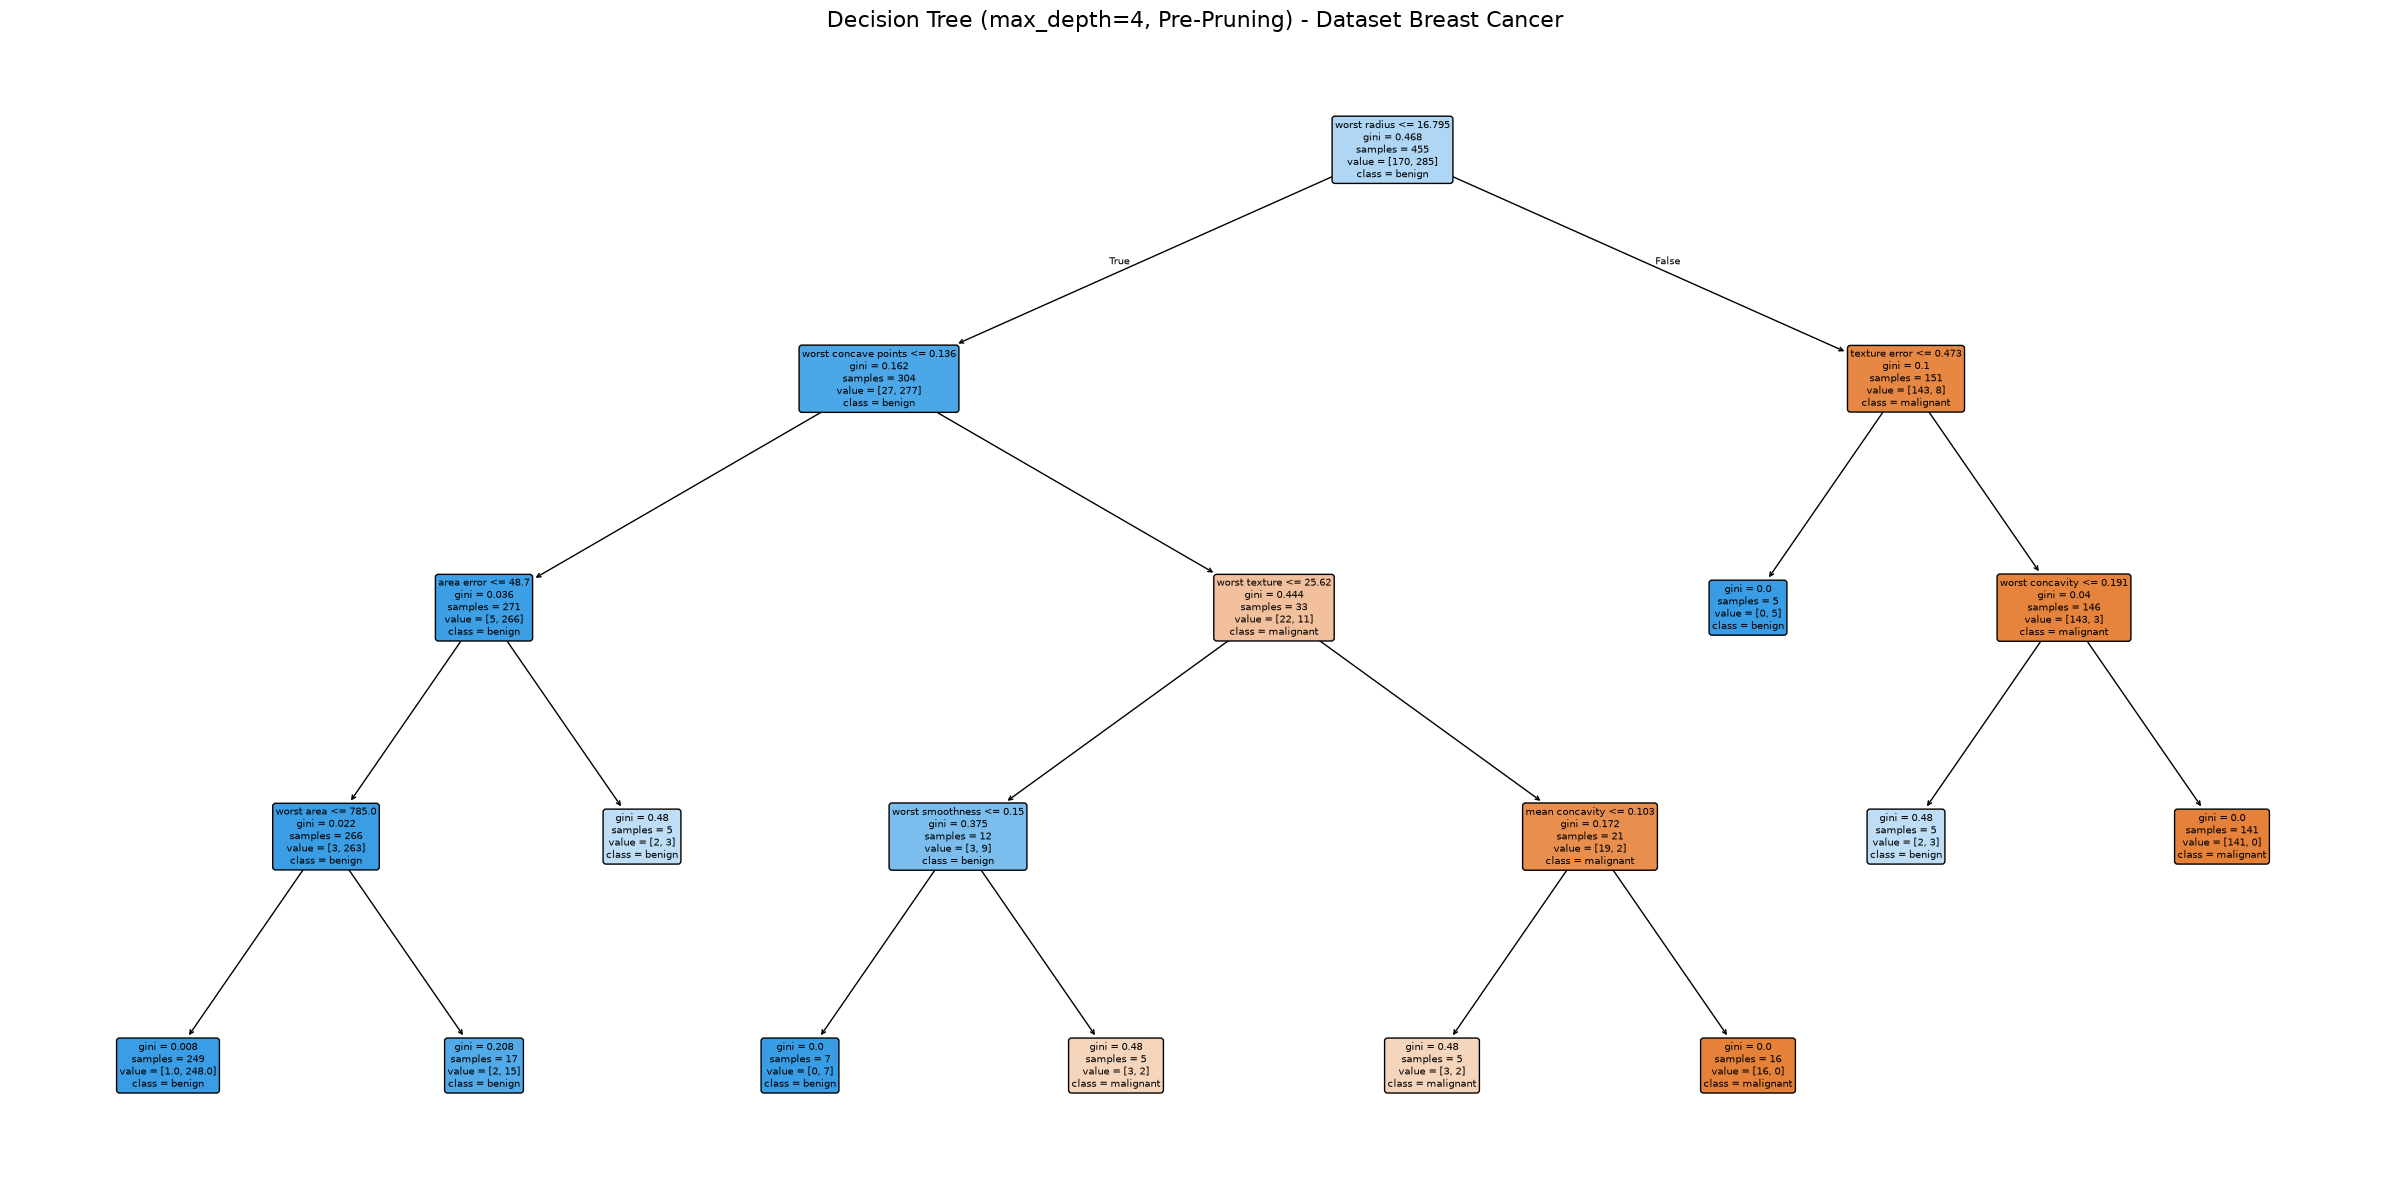

In [6]:
plt.figure(figsize=(24, 12))
plot_tree(
    tree_pruned,
    feature_names=feature_names,
    class_names=target_names,
    filled=True, rounded=True, fontsize=7,
)
plt.title("Decision Tree (max_depth=4, Pre-Pruning) - Dataset Breast Cancer",
          fontsize=16)
plt.tight_layout()
plt.show()

**Penjelasan outputnya:**
1. Pohonnya kegambar rapi: **10 leaf node**, kedalamannya pas **4**. Sesuai batas `max_depth=4`.
2. Node akar ngebelah berdasar fitur dengan Gini impurity awal **0.469** (mendekati 0.5 karena dua kelasnya cukup berimbang). Terus tiap cabang milih split yang nurunin impurity.
3. Warna node nunjukin kelas dominan: makin pekat biru/oranyenya makin murni node-nya. Sebagian besar daun udah murni banget (Gini mendekati 0).
4. Tiap jalur akar ke daun kebaca sebagai aturan, misalnya *"kalo worst concave points <= sekian, berarti benign"*. Nah ini nih keunggulan interpretabilitas decision tree.

### 5.11.1 Interpretasi (Modul Bab 5)

- Pohon **tanpa pruning** punya gap train-test paling gede (0.0877). Overfitting.
- **Pre-pruning** (`max_depth=4`, `min_samples_leaf=5`) sama **post-pruning** (`ccp_alpha`) dua-duanya **nyempitin gap** (ke 0.0548 dan 0.0482) walau akurasi train turun dikit. Ini bias-variance trade-off yang sehat.
- Jangan milih nilai pruning dari sekali tebak doang. Pake **kurva validasi** (Eksperimen 1) atau **pruning path** (Latihan 2) buat milih `alpha` secara sistematis.

## Eksperimen (Coba-Coba)

Bagian ini isinya percobaan mandiri: saya ubah-ubah parameter terus ngamatin dampaknya ke performa sama bentuk pohon.

### Eksperimen 1 - Pengaruh `max_depth` 1 sampai 10 (kurva validasi manual)

Bagian ini saya ngerjain Eksperimen 1 dari Modul Machine Learning Bab 5. Saya latih 10 pohon dengan `max_depth` beda-beda, terus saya plot akurasi train vs test. Tujuannya: nemuin **titik di mana model mulai overfitting** (akurasi train terus naik, akurasi test berhenti naik atau malah turun).

max_depth= 1 | akurasi train = 0.9231 | akurasi test = 0.9211
max_depth= 2 | akurasi train = 0.9582 | akurasi test = 0.8947
max_depth= 3 | akurasi train = 0.9758 | akurasi test = 0.9386
max_depth= 4 | akurasi train = 0.9868 | akurasi test = 0.9386
max_depth= 5 | akurasi train = 0.9934 | akurasi test = 0.9211
max_depth= 6 | akurasi train = 0.9978 | akurasi test = 0.9123
max_depth= 7 | akurasi train = 1.0000 | akurasi test = 0.9123
max_depth= 8 | akurasi train = 1.0000 | akurasi test = 0.9123
max_depth= 9 | akurasi train = 1.0000 | akurasi test = 0.9123
max_depth=10 | akurasi train = 1.0000 | akurasi test = 0.9123


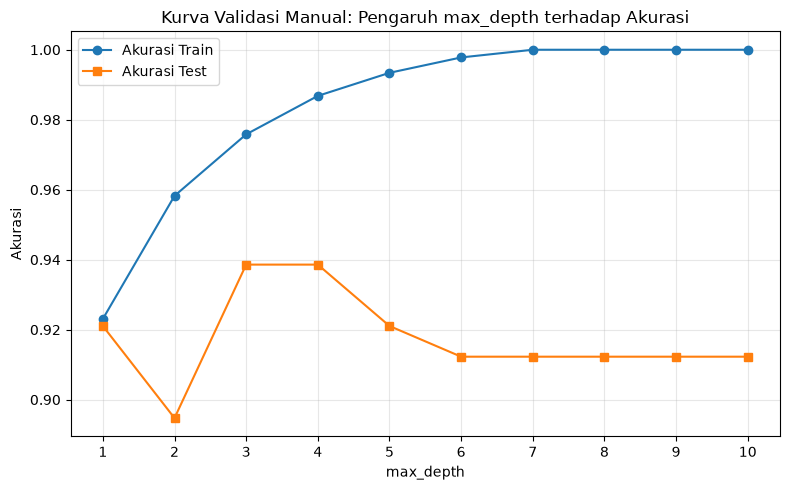

In [7]:
depths = list(range(1, 11))
ak_train, ak_test = [], []

for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=42)
    m.fit(X_train, y_train)
    ak_train.append(accuracy_score(y_train, m.predict(X_train)))
    ak_test.append(accuracy_score(y_test, m.predict(X_test)))
    print(f"max_depth={d:2d} | akurasi train = {ak_train[-1]:.4f} | "
          f"akurasi test = {ak_test[-1]:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(depths, ak_train, marker="o", label="Akurasi Train")
plt.plot(depths, ak_test, marker="s", label="Akurasi Test")
plt.xlabel("max_depth")
plt.ylabel("Akurasi")
plt.title("Kurva Validasi Manual: Pengaruh max_depth terhadap Akurasi")
plt.xticks(depths)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Penjelasan outputnya:**
1. Akurasi **train naik terus** dari 0.9231 (depth=1) sampe **1.0000** di depth 7 ke atas. Pohon makin dalam makin jago ngapalin data latih.
2. Akurasi **test mentok di 0.9386 pada depth 3-4**, terus **turun ke 0.9123** dan stagnan di depth 6 ke atas. Kurvanya naik dulu terus turun.
3. **Titik overfitting** keliatan jelas di sekitar **depth 5-6**: abis itu kurva train sama test **melebar** (gap makin gede). Model makin kompleks tapi kemampuan generalisasinya nggak nambah.
4. Ini ngebenarin pilihan `max_depth=4` di Praktikum 5.4: pas banget di puncak kurva validasi.

### Eksperimen 2 - `min_samples_leaf=1` vs `20` pada pohon tanpa batas

Bagian ini saya ngerjain Eksperimen 2 dari Modul Machine Learning Bab 5. `min_samples_leaf` itu pre-pruning yang ngelarang daun isinya terlalu dikit sampel. Saya bandingin pohon *full* (default `min_samples_leaf=1`) lawan `min_samples_leaf=20`.

In [8]:
print(f"{'min_samples_leaf':>16s} | {'Akurasi Train':>13s} | "
      f"{'Akurasi Test':>12s} | {'Gap':>6s} | {'Daun':>4s} | {'Kedalaman':>9s}")
print("-" * 80)
for msl in [1, 20]:
    m = DecisionTreeClassifier(min_samples_leaf=msl, random_state=42)
    m.fit(X_train, y_train)
    ak_tr = accuracy_score(y_train, m.predict(X_train))
    ak_te = accuracy_score(y_test, m.predict(X_test))
    print(f"{msl:16d} | {ak_tr:13.4f} | {ak_te:12.4f} | {ak_tr-ak_te:6.4f} | "
          f"{m.get_n_leaves():4d} | {m.get_depth():9d}")

min_samples_leaf | Akurasi Train | Akurasi Test |    Gap | Daun | Kedalaman
--------------------------------------------------------------------------------
               1 |        1.0000 |       0.9123 | 0.0877 |   19 |         7
              20 |        0.9473 |       0.9035 | 0.0437 |    7 |         4


**Penjelasan outputnya:**
1. `min_samples_leaf=1`: **19 daun**, kedalaman 7, akurasi train **1.0000** vs test **0.9123** (gap 0.0877). Pohon penuh yang overfitting.
2. `min_samples_leaf=20`: daunnya nyusut drastis jadi **7**, kedalaman 4, train **0.9473** vs test **0.9035** (gap cuma 0.0438).
3. Ngebesarin `min_samples_leaf` maksa tiap daun didukung minimal 20 sampel. Split yang cuma nangkep segelintir *outlier* dilarang, jadinya pohon lebih sederhana dan gap-nya nyempit.
4. Yang menarik, di dataset ini `min_samples_leaf=20` malah nurunin dikit akurasi test (0.9035 < 0.9123): pruning yang **terlalu agresif** malah bikin *underfitting*. Nilai tengah (misal 5-10) lebih seimbang, sesuai hasil grid di Latihan 1.

### Eksperimen 3 - Decision Tree vs Random Forest kecil (`n_estimators=50`)

Bagian ini saya ngerjain Eksperimen 3 dari Modul Machine Learning Bab 5. Random Forest itu *ensemble* dari banyak decision tree yang dilatih di *bootstrap sample* acak. Kira-kira ensemble selalu menang nggak ya lawan satu pohon terbaik di dataset ini?

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=50, random_state=42)
rf.fit(X_train, y_train)

ak_tr_tree = accuracy_score(y_train, tree_pruned.predict(X_train))
ak_te_tree = accuracy_score(y_test, tree_pruned.predict(X_test))
ak_tr_rf = accuracy_score(y_train, rf.predict(X_train))
ak_te_rf = accuracy_score(y_test, rf.predict(X_test))

print(f"{'Model':35s} | {'Akurasi Train':>13s} | {'Akurasi Test':>12s}")
print("-" * 70)
print(f"{'Decision Tree (max_depth=4, pruned)':35s} | {ak_tr_tree:13.4f} | "
      f"{ak_te_tree:12.4f}")
print(f"{'Random Forest (50 pohon)':35s} | {ak_tr_rf:13.4f} | {ak_te_rf:12.4f}")

Model                               | Akurasi Train | Akurasi Test
----------------------------------------------------------------------
Decision Tree (max_depth=4, pruned) |        0.9758 |       0.9211
Random Forest (50 pohon)            |        1.0000 |       0.9561


**Penjelasan outputnya:**
1. Random Forest (50 pohon): akurasi test **0.9561**, ngalahin decision tree tunggal yang udah di-pruning (0.9211). Selisihnya **3.5 poin**.
2. Akurasi train RF nyampe **1.0000** tapi gap-nya (0.0439) tetep kecil. *Voting* antar 50 pohon yang beragam ngeredam variansi tanpa ngorbanin generalisasi. Ini inti cara kerja ensemble.
3. Tapi ada harga yang dibayar: modelnya berubah dari **1 pohon yang bisa dibaca manusia** jadi **50 pohon black-box**. Interpretabilitasnya ilang.
4. Kesimpulannya: ensemble **cenderung menang di akurasi** di dataset ini, tapi decision tree tetep unggul kalo **aturan yang bisa dijelasin** (misal buat dokter) lebih penting daripada selisih beberapa persen akurasi.

## 5.9 Studi Kasus - Prediksi Risiko Diabetes yang Interpretable (Modul Bab 5)

| | |
|---|---|
| **Masalah** | Rumah sakit butuh model prediksi faktor risiko diabetes yang **akurat DAN gampang dipahami** tenaga medis non-teknis. Model black-box (misal deep learning) ditolak dokter karena alasannya nggak bisa dijelasin ke pasien. |
| **Solusi & Proses** | Dipake **Decision Tree**: tiap jalur akar ke daun kebaca sebagai aturan klinis, misal *"kalo glukosa > 140 dan BMI > 30, berarti risiko tinggi"*. Pohon penuh (tanpa pruning) nyampe akurasi latih 99% tapi uji cuma 71% (overfitting). Terus diterapin **post-pruning** dengan `ccp_alpha` yang dipilih via cross-validation. |
| **Hasil** | Akurasi latih turun ke 85% tapi akurasi **uji naik ke 79%**. Gap-nya nyempit, modelnya menggeneralisasi. Pohonnya nyusut dari **puluhan level jadi 4-5 level**, jauh lebih gampang diinterpretasi dan dipresentasiin ke tim medis. |
| **Interpretasi** | Turunnya akurasi latih itu **biaya yang wajar** buat generalisasi. Di dunia medis, model yang dikit kurang akurat tapi **transparan dan stabil** lebih berguna daripada model yang sempurna di data latih tapi gagal di pasien baru. |

**Pembahasan.** Studi kasus ini nunjukin alasan utama decision tree tetep relevan di era deep learning: *interpretability*. Pruning bukan sekadar trik buat naikin akurasi. Pruning ngubah model yang mustahil dijelasin (puluhan level) jadi **dokumen keputusan** yang bisa ditempel di dinding ruang periksa. Contoh aturannya pun langsung bisa dipake:

> **Contoh aturan terbaca:** *kalo glukosa darah puasa > 140 mg/dL **dan** BMI > 30, pasien berisiko tinggi diabetes; kalo glukosa <= 140 **dan** riwayat keluarga negatif, risiko rendah.*

Praktikum 5.4 dan 5.5 di atas nereplikasi pola yang sama di dataset Breast Cancer: `tree_ccp` (post-pruning) ngasih gap paling kecil (0.0482) dengan pohon cuma 7 daun. Akurat *dan* ringkas.

## 5.10 Contoh Perhitungan - Gini, Entropy, Information Gain (Modul Bab 5)

Bagian ini saya ngerjain Contoh Perhitungan dari Modul Machine Learning Bab 5. Diketahui sebuah **node isinya 10 data: 6 Positif, 4 Negatif**. Saya hitung manual ketidakmurnian node-nya, terus Information Gain dari sebuah kandidat split.

### Langkah 1 - Probabilitas kelas
```
p_pos = 6/10 = 0,6
p_neg = 4/10 = 0,4
```

### Langkah 2 - Gini impurity
```
Gini = 1 - (p_pos^2 + p_neg^2)
     = 1 - (0,6^2 + 0,4^2)
     = 1 - (0,36 + 0,16)
     = 1 - 0,52
     = 0,48
```

### Langkah 3 - Entropy
```
Entropy = -(p_pos * log2(p_pos) + p_neg * log2(p_neg))
        = -(0,6 * log2(0,6) + 0,4 * log2(0,4))

log2(0,6) = -0,737   ->   0,6 * (-0,737) = -0,442
log2(0,4) = -1,322   ->   0,4 * (-1,322) = -0,529

Entropy = -(-0,442 - 0,529) = 0,971
```

### Langkah 4 - Kandidat split pada fitur X
Split-nya ngebagi node jadi:
- **Kiri:** 4 data (4 Pos, 0 Neg), udah **murni**, Entropy(kiri) = 0
- **Kanan:** 6 data (2 Pos, 4 Neg) -> p_pos = 2/6 = 1/3, p_neg = 4/6 = 2/3

```
Entropy(kanan) = -((1/3) * log2(1/3) + (2/3) * log2(2/3))
               = -((1/3) * (-1,585) + (2/3) * (-0,585))
               = -(-0,528 - 0,390)
               = 0,918
```

### Langkah 5 - Entropy tertimbang & Information Gain
```
Entropy_tertimbang = (4/10) * 0 + (6/10) * 0,918 = 0,551
Information Gain   = 0,971 - 0,551 = 0,420
```

IG sebesar 0,420 terus **dibandingin sama IG kandidat split lain**. Split dengan IG tertinggi yang dipilih.

### Verifikasi dengan Python
Perhitungan manual di atas saya verifikasi ulang pake `numpy`:


In [10]:
import numpy as np

# Node: 10 data -> 6 Positif, 4 Negatif
p_pos, p_neg = 6/10, 4/10

gini = 1 - (p_pos**2 + p_neg**2)
entropy = -(p_pos*np.log2(p_pos) + p_neg*np.log2(p_neg))

# Split: kiri 4 data (4 Pos, 0 Neg) -> murni; kanan 6 data (2 Pos, 4 Neg)
entropy_kiri = 0.0
p_r_pos, p_r_neg = 2/6, 4/6
entropy_kanan = -(p_r_pos*np.log2(p_r_pos) + p_r_neg*np.log2(p_r_neg))

entropy_tertimbang = (4/10)*entropy_kiri + (6/10)*entropy_kanan
info_gain = entropy - entropy_tertimbang

print(f"Gini              = {gini:.3f}")
print(f"Entropy           = {entropy:.3f}")
print(f"Entropy(kanan)    = {entropy_kanan:.3f}")
print(f"Entropy tertimbang= {entropy_tertimbang:.3f}")
print(f"Information Gain  = {info_gain:.3f}")

Gini              = 0.480
Entropy           = 0.971
Entropy(kanan)    = 0.918
Entropy tertimbang= 0.551
Information Gain  = 0.420


**Penjelasan outputnya:**
1. Hasil kodenya **persis sama** kayak hitungan manual: Gini = **0.480**, Entropy = **0.971**, Entropy(kanan) = **0.918**, Entropy tertimbang = **0.551**, Information Gain = **0.420**. Terbukti tanpa selisih pembulatan.
2. Nilai Entropy 0.971 mendekati 1 (maksimum buat 2 kelas). Node awal emang cukup nggak murni, wajar karena proporsinya 6:4.
3. Split yang diuji bagus: cabang kiri jadi **murni sempurna** (Entropy 0) makanya IG-nya gede (0.420). Split kayak gini nih yang bakal dipilih algoritma CART/ID3.

## 5.12 Latihan Praktikum (Modul Bab 5)

> Dua latihan di bawah ini **saya kerjain** langsung (soal + kode + jawaban).

### Latihan 1 - Eksperimen Parameter Pre-Pruning (Modul Bab 5, bagian 5.12)

**Soal:** Lakuin grid search manual atas kombinasi `max_depth` di {2, 4, 6, None} x `min_samples_leaf` di {1, 5, 10}. Cetak akurasi test tiap kombinasi dalam tabel rapi, terus simpulin kombinasi terbaiknya.

In [11]:
print(f"{'max_depth':>10s} | {'min_samples_leaf':>16s} | {'Akurasi Test':>12s}")
print("-" * 46)

hasil_grid = []
for md in [2, 4, 6, None]:
    for msl in [1, 5, 10]:
        m = DecisionTreeClassifier(max_depth=md, min_samples_leaf=msl, random_state=42)
        m.fit(X_train, y_train)
        ak = accuracy_score(y_test, m.predict(X_test))
        hasil_grid.append((ak, md, msl))
        print(f"{str(md):>10s} | {msl:16d} | {ak:12.4f}")

terbaik = max(hasil_grid, key=lambda t: t[0])
print(f"\nKombinasi terbaik: max_depth={terbaik[1]}, min_samples_leaf={terbaik[2]} "
      f"-> akurasi test {terbaik[0]:.4f}")

 max_depth | min_samples_leaf | Akurasi Test
----------------------------------------------
         2 |                1 |       0.8947
         2 |                5 |       0.8947
         2 |               10 |       0.9035
         4 |                1 |       0.9386
         4 |                5 |       0.9211
         4 |               10 |       0.9474
         6 |                1 |       0.9123
         6 |                5 |       0.9298
         6 |               10 |       0.9474
      None |                1 |       0.9123
      None |                5 |       0.9298
      None |               10 |       0.9474

Kombinasi terbaik: max_depth=4, min_samples_leaf=10 -> akurasi test 0.9474


**Penjelasan outputnya:**
1. Dari 12 kombinasi, akurasi test tertinggi itu **0.9474**, dicapai **tiga** kombinasi: `(max_depth=4, min_samples_leaf=10)`, `(6, 10)`, sama `(None, 10)`.
2. Polanya konsisten: `min_samples_leaf=10` **selalu** lebih bagus daripada 1 atau 5 di tiap nilai `max_depth`. Ngebatasin daun minimum itu pre-pruning yang efektif di dataset ini.
3. `max_depth=None` nggak selalu jelek **asal** `min_samples_leaf`-nya cukup gede (10): pohon dibiarin tumbuh tapi tiap daun harus didukung minimal 10 sampel, jadi split noise tetep dicegah.
4. **Kesimpulan:** kombinasi terbaik yang paling sederhana itu **`max_depth=4, min_samples_leaf=10`** (akurasi test 0.9474). Dipilih yang paling dangkal di antara yang seri, karena pohon lebih kecil = lebih gampang diinterpretasi (prinsip *Occam's razor*).

### Latihan 2 - Cost Complexity Pruning Path (Modul Bab 5, bagian 5.12)

**Soal:** Buat tiap `alpha` di `path.ccp_alphas`, latih decision tree dan catat akurasi test-nya. Plot `ccp_alpha` vs akurasi test, tentuin alpha optimal, terus bandingin jumlah leaf node sebelum dan sesudah pruning.

 ccp_alpha | Akurasi Test | Jumlah Daun
-----------------------------------------
  0.000000 |       0.9123 |          19
  0.002181 |       0.9211 |          15
  0.002866 |       0.9386 |          12
  0.002930 |       0.9386 |          11
  0.003956 |       0.9386 |          10
  0.004251 |       0.9386 |           9
  0.005024 |       0.9386 |           8
  0.005275 |       0.9298 |           7
  0.005934 |       0.9386 |           6
  0.007641 |       0.9386 |           5
  0.014390 |       0.8947 |           4
  0.020386 |       0.9035 |           3
  0.054334 |       0.9211 |           2
  0.326617 |       0.6316 |           1

Alpha optimal: 0.002866 -> akurasi test 0.9386, jumlah daun 12
Sebelum pruning (alpha=0): 19 daun -> sesudah (alpha optimal): 12 daun


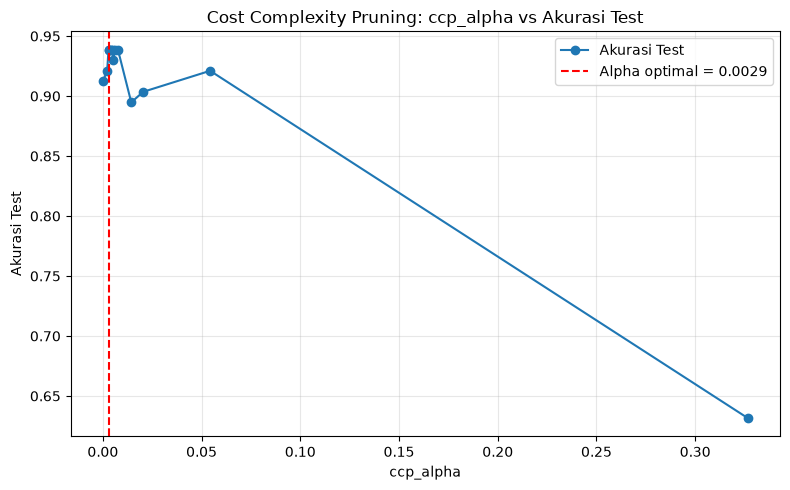

In [12]:
alphas = path.ccp_alphas
ak_test_ccp, n_daun = [], []

for a in alphas:
    m = DecisionTreeClassifier(ccp_alpha=a, random_state=42)
    m.fit(X_train, y_train)
    ak_test_ccp.append(accuracy_score(y_test, m.predict(X_test)))
    n_daun.append(m.get_n_leaves())

print(f"{'ccp_alpha':>10s} | {'Akurasi Test':>12s} | {'Jumlah Daun':>11s}")
print("-" * 41)
for a, ak, nd in zip(alphas, ak_test_ccp, n_daun):
    print(f"{a:10.6f} | {ak:12.4f} | {nd:11d}")

idx_opt = int(np.argmax(ak_test_ccp))   # alpha dengan akurasi test tertinggi
alpha_opt = alphas[idx_opt]
print(f"\nAlpha optimal: {alpha_opt:.6f} -> akurasi test {ak_test_ccp[idx_opt]:.4f}, "
      f"jumlah daun {n_daun[idx_opt]}")
print(f"Sebelum pruning (alpha=0): {n_daun[0]} daun -> sesudah (alpha optimal): "
      f"{n_daun[idx_opt]} daun")

plt.figure(figsize=(8, 5))
plt.plot(alphas, ak_test_ccp, marker="o", label="Akurasi Test")
plt.axvline(alpha_opt, color="red", linestyle="--",
            label=f"Alpha optimal = {alpha_opt:.4f}")
plt.xlabel("ccp_alpha")
plt.ylabel("Akurasi Test")
plt.title("Cost Complexity Pruning: ccp_alpha vs Akurasi Test")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Penjelasan outputnya:**
1. Di `alpha=0` (tanpa pruning): 19 daun, akurasi test 0.9123. Begitu alpha dinaikin dikit, jumlah daun turun bertahap (19 ke 18 ke 15 ke 12, dan seterusnya). Cabang yang lemah dipangkas satu per satu.
2. **Alpha optimal = 0.002866** dengan akurasi test **0.9386** dan **12 daun**. Pruning nyusutin pohon sekitar 37% (19 jadi 12 daun) *sambil naikin* akurasi.
3. Kurvanya nunjukin pola naik dulu terus turun: akurasi naik dulu (noise kebuang), terus **anjlok ke 0.6316** di alpha maksimum (0.3266) pas pohon tinggal 1 daun. Pruning berlebihan = underfitting.
4. Perbandingannya: sebelum pruning 19 daun (akurasi 0.9123) vs sesudah pruning optimal 12 daun (akurasi 0.9386). Post-pruning terbukti ngasih model yang **lebih kecil DAN lebih akurat**.

## Kesimpulan Bab 5

1. **Decision tree** ngebagi data secara rekursif pake kriteria impurity (Gini/Entropy). Tiap jalur akar ke daun kebaca sebagai aturan `if-then`, makanya model ini unggul di interpretabilitas dibanding model black-box.
2. **Pohon tanpa batas ngalamin overfitting**: akurasi train 100% tapi test cuma 0.9123 (gap 0.0877) di dataset Breast Cancer. Kompleksitas berlebih ngapalin noise.
3. **Pre-pruning** (`max_depth`, `min_samples_leaf`) sama **post-pruning** (`ccp_alpha`) dua-duanya nyempitin gap train-test. Di praktikum ini `tree_ccp` ngasih hasil terbaik (test 0.9298, gap 0.0482, cuma 7 daun).
4. **Parameter pruning jangan asal tebak**: kurva validasi manual (Eksperimen 1) sama *cost complexity pruning path* (Latihan 2) ngasih cara sistematis buat milih `max_depth`/`alpha` yang optimal. Titik overfitting keliatan jelas pas kurva train sama test melebar.
5. **Ensemble (Random Forest)** ngalahin pohon tunggal di akurasi (0.9561 vs 0.9211) dengan ngorbanin interpretabilitas. Pilih sesuai kebutuhan: aturan yang bisa dijelasin (medis/hukum) vs akurasi maksimum.